In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
# AT - Temperature
# V - vaccum
# AP - pressure
# RH - humidity

#PE - Produced Energy

In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [7]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [8]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [9]:
# Load the data
# convert the data into pytorch tensor
# create tensor dataset and data loader
# Define ANN model
# Actually train the model and save the model
# Evaluate the model

In [10]:
# Split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state=42)

In [11]:
X_train.head()

,AT,V,AP,RH
5487,25.24,63.47,1011.30,66.21
3522,26.09,70.40,1007.41,85.37
6916,26.63,73.68,1015.15,85.13
7544,32.06,71.85,1007.90,56.44
7600,28.70,71.64,1007.11,69.85


In [12]:
df.shape

(9568, 5)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [14]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]],
      shape=(7654, 4))

In [15]:
import torch
import torch.nn as nn

In [16]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)


In [17]:
type(y_train)

pandas.Series

In [18]:
type(X_train_scaled)


numpy.ndarray

In [19]:
type(X_train_tensor)

torch.Tensor

In [20]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [21]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## Deep Learning

In [22]:
# Build our ANN model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
        # 1st hidden layer
        nn.Linear(X_train.shape[1],6), # Calculates Z, then we apply Relu
        nn.ReLU(),

        #2nd hidden layer
        nn.Linear(6,6), # Calculates Z, then we apply Relu
        nn.ReLU(),

        #Output layer
        nn.Linear(6,1),
        
    )

    def forward(self, x):
        return self.model(x)
        

In [23]:
import torch.optim as optim
model = ANN()

#loss, optimizer
criteria = nn.MSELoss()
optimiser = optim.Adam(model.parameters())

In [29]:
# Train the ANN
train_losses = []
epochs = 100
val_losses = []
best_val_loss = float("inf")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch

    for xb, yb in train_loader:
        #xb = features of 1 batch
        # yb = lables of 1 batch
        optimiser.zero_grad()
        outputs = model(xb) #Predicted outputs for this batch
        loss = criteria(outputs, yb) # Compute loss
        loss.backward() # back prop.. compute gradients
        optimiser.step() # adjust param
        running_loss += loss.item() # loss is a tensor value, which we need to convert 
        
    epoch_train_loss = running_loss /len(test_loader)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_validation_loss = 0.0
    with torch.no_grad(): # no need to compute any gradiant in this step
        for xb, yb in test_loader:
            model.eval()
            outputs = model(xb)
            loss = criteria(outputs, yb) # Compute loss
            running_validation_loss += loss
    epoch_val_loss = running_validation_loss /len(train_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch${epoch+1}/{epochs} ==> training loss = ${epoch_train_loss} & val loss = $ {epoch_val_loss}")
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") # .pt ot .pth

epoch$1/100 ==> training loss = $78.34931619962056 & val loss = $ 4.638646125793457
epoch$2/100 ==> training loss = $78.49341761271158 & val loss = $ 4.4690632820129395
epoch$3/100 ==> training loss = $78.67074448267618 & val loss = $ 4.517827987670898
epoch$4/100 ==> training loss = $78.3675832271576 & val loss = $ 4.444039821624756
epoch$5/100 ==> training loss = $79.0088767528534 & val loss = $ 4.467807292938232
epoch$6/100 ==> training loss = $78.69921595255533 & val loss = $ 4.524353981018066
epoch$7/100 ==> training loss = $77.9612865447998 & val loss = $ 4.48516321182251
epoch$8/100 ==> training loss = $78.54803791046143 & val loss = $ 4.6717529296875
epoch$9/100 ==> training loss = $78.17579925855001 & val loss = $ 4.53667688369751
epoch$10/100 ==> training loss = $78.8874964872996 & val loss = $ 4.51941442489624
epoch$11/100 ==> training loss = $79.28659496307372 & val loss = $ 4.685833930969238
epoch$12/100 ==> training loss = $79.20096670786539 & val loss = $ 4.5253577232360

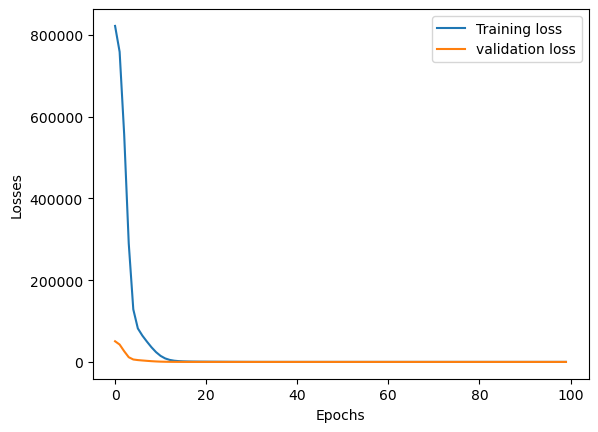

In [25]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "train_loss":train_losses,
    "val_loss": val_losses,
})

plt.plot(loss_df["train_loss"], label = "Training loss")
plt.plot(loss_df["val_loss"], label = "validation loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [28]:
# Saving our best performing model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [33]:
# Evaluate model

import torch.nn as nn

# Define the loss function
criterion = nn.MSELoss()

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)

    print("Training train_mse_loss : ",train_mse_loss)
    print("Testing test_mse_loss : ",test_mse_loss)
    
    

Training train_mse_loss :  tensor(19.5331)
Testing test_mse_loss :  tensor(18.2206)


In [34]:
from sklearn.metrics import r2_score

print("r^2 : ", r2_score(y_test, test_preds))

r^2 :  0.9363238040824438
